# NeurIPS Analysis v4 — DAG Readiness

Validates the panel for Bayesian DAG structure learning with LLM priors.

1. Data quality audit
2. Topic taxonomy validation
3. Core variable health (prof's 8 variables)
4. Temporal diagnostics (autocorrelation, stationarity, within/between variance)
5. Predictor → outcome relationships
6. Modularity & bridge concentration quality check
7. DAG readiness scorecard

## 1. Setup & load

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

!pip install -q scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

OUT_DIR = '/content/drive/MyDrive/openalex_enrich_out'
EXPORT_DIR = f'{OUT_DIR}/dag_learning_ready'
COMPLETE = {'ok', 'ok_fallback', 'ok_manual_doi', 'ok_refetch'}
EXCLUDE_YEAR = 2024

orig = pd.read_csv(f'{OUT_DIR}/nips-papers_enriched_openalex.csv') if os.path.exists(f'{OUT_DIR}/nips-papers_enriched_openalex.csv') else None
fixed = pd.read_csv(f'{OUT_DIR}/nips-papers-fixed.csv') if os.path.exists(f'{OUT_DIR}/nips-papers-fixed.csv') else None
c2 = pd.read_csv(f'{OUT_DIR}/nips-papers-c2.csv') if os.path.exists(f'{OUT_DIR}/nips-papers-c2.csv') else None
panel = pd.read_csv(f'{OUT_DIR}/nips-panel-v4.csv') if os.path.exists(f'{OUT_DIR}/nips-panel-v4.csv') else None

vardesc = None
for p in [f'{OUT_DIR}/nips-variable-descriptions.json', f'{EXPORT_DIR}/variable_descriptions.json']:
    if os.path.exists(p):
        with open(p) as f:
            vardesc = json.load(f)
        break

for name, df in [('orig', orig), ('fixed', fixed), ('c2', c2), ('panel', panel)]:
    if df is not None:
        print(name, df.shape)


Mounted at /content/drive
orig (20326, 25)
fixed (20326, 27)
c2 (20326, 30)
panel (156, 21)


## 2. Data quality audit

orig 20326 100.0%
{'oa_cited_by_count': 0.92, 'oa_primary_topic': 0.804, 'oa_author_ids_json': 0.92, 'oa_doi': 0.743}
fixed 20326 98.6%
{'oa_cited_by_count': 1.0, 'oa_primary_topic': 0.882, 'oa_author_ids_json': 1.0, 'oa_doi': 0.819}


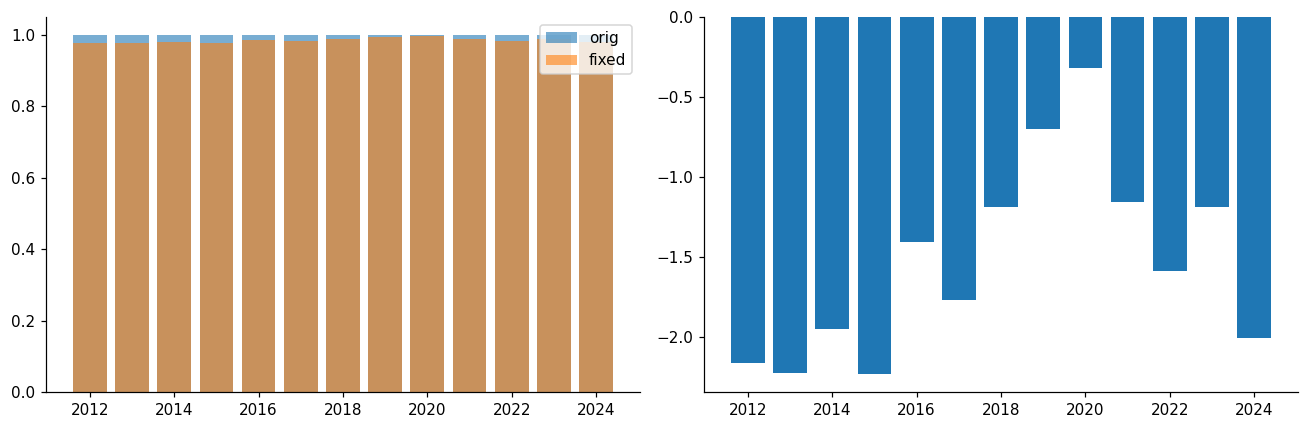

In [ ]:
for name, df in [('orig', orig), ('fixed', fixed)]:
    if df is None:
        continue
    ok = df[df['oa_status'].isin(COMPLETE)]
    print(name, len(df), f'{len(ok)/len(df):.1%}')
    cols = [c for c in ['oa_cited_by_count', 'oa_primary_topic', 'oa_author_ids_json', 'oa_doi'] if c in ok.columns]
    print(ok[cols].notna().mean().round(3).to_dict())

if orig is not None and fixed is not None:
    y = pd.DataFrame({'year': sorted(fixed['year'].unique())})
    y['orig'] = y['year'].map(orig.groupby('year')['oa_status'].apply(lambda s: s.isin(COMPLETE).mean()))
    y['fixed'] = y['year'].map(fixed.groupby('year')['oa_status'].apply(lambda s: s.isin(COMPLETE).mean()))
    y['delta_pp'] = 100 * (y['fixed'] - y['orig'])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(y['year'], y['orig'], alpha=0.6, label='orig')
    axes[0].bar(y['year'], y['fixed'], alpha=0.6, label='fixed')
    axes[0].legend()
    axes[1].bar(y['year'], y['delta_pp'])
    plt.tight_layout()
    plt.show()


## 3. Topic taxonomy

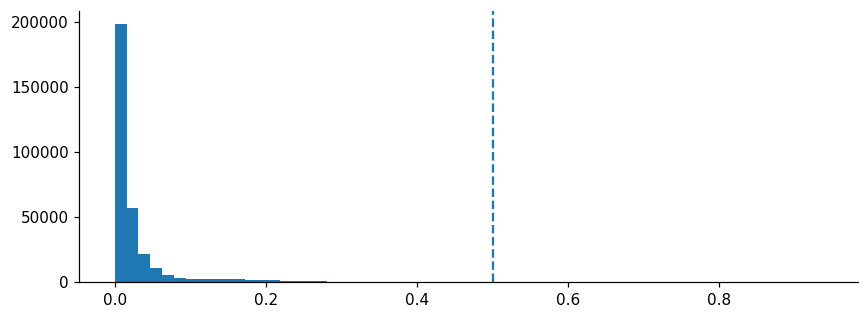

801 290
110 80


In [ ]:
if fixed is not None:
    topics = sorted(fixed.loc[fixed['oa_status'].isin(COMPLETE) & fixed['oa_primary_topic'].notna(), 'oa_primary_topic'].str.strip().unique())
    sim = cosine_similarity(TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5)).fit_transform(topics))
    upper = sim[np.triu_indices_from(sim, k=1)]
    plt.figure(figsize=(8, 3))
    plt.hist(upper, bins=60)
    plt.axvline(0.50, ls='--')
    plt.tight_layout()
    plt.show()
    print(len(topics), int((upper >= 0.50).sum()))
    if os.path.exists(f'{OUT_DIR}/nips-topic-merge-map.json'):
        merge_map = json.load(open(f'{OUT_DIR}/nips-topic-merge-map.json'))
        print(len(merge_map), len(set(merge_map.values())))


## 4. Core variable health (prof's 8 variables)

(156, 21) 29 2013-2023
                         count  missing  miss%   mean    std    min     max   skew
topic_share_t1           156.0        0    0.0  0.039  0.027  0.004   0.115  0.716
cross_topic_rate_t1      156.0        0    0.0  0.265  0.064  0.133   0.483  0.418
connectivity_t1          156.0        0    0.0  3.819  1.388  2.050  13.761  3.018
modularity_t1            156.0        0    0.0  0.915  0.056  0.615   0.987 -1.913
bridge_concentration_t1  156.0        0    0.0  0.853  0.347  0.000   1.000 -2.068
topic_growth             156.0        0    0.0  0.038  0.277 -0.641   0.752  0.001
median_cites_2yr         156.0        0    0.0  3.093  3.141  0.000  19.000  1.989
hit_rate_2yr             156.0        0    0.0  0.111  0.107  0.000   0.486  1.230


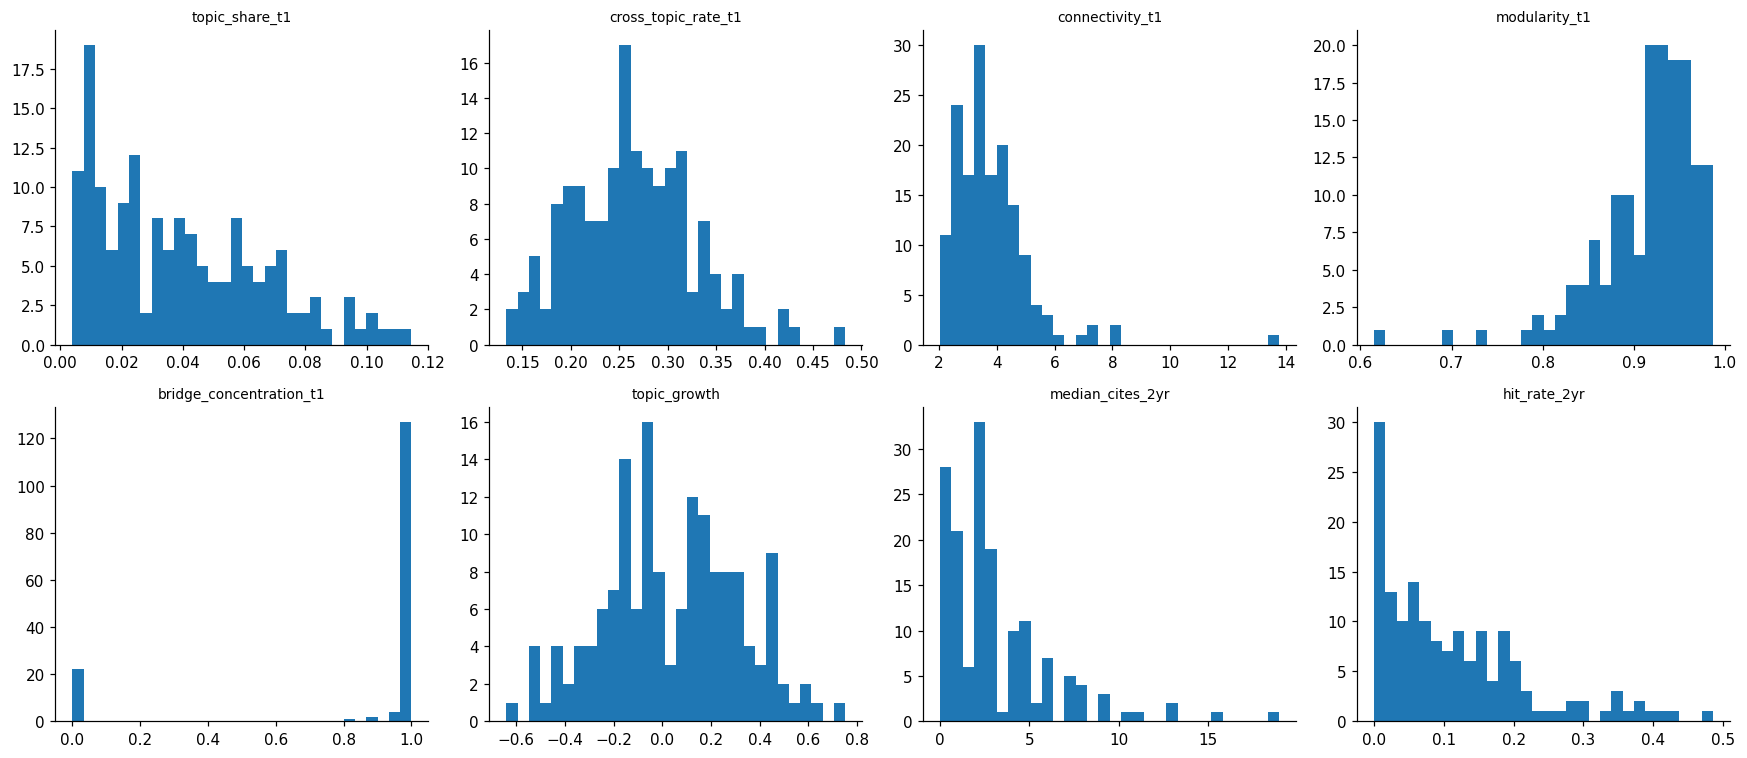

156 156


In [ ]:
if panel is not None:
    core = [c for c in ['topic_share_t1', 'cross_topic_rate_t1', 'connectivity_t1', 'modularity_t1', 'bridge_concentration_t1', 'topic_growth', 'median_cites_2yr', 'hit_rate_2yr'] if c in panel.columns]
    desc = panel[core].describe().T
    desc['missing'] = panel[core].isna().sum()
    desc['miss%'] = (100 * panel[core].isna().mean()).round(1)
    desc['skew'] = panel[core].skew()
    print(panel.shape, panel['topic'].nunique(), f"{panel['year'].min()}-{panel['year'].max()}")
    print(desc[['count', 'missing', 'miss%', 'mean', 'std', 'min', 'max', 'skew']].round(3).to_string())

    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.ravel()
    for ax, col in zip(axes, core):
        ax.hist(panel[col].dropna(), bins=30)
        ax.set_title(col, fontsize=9)
    for ax in axes[len(core):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

    print(int(panel[core].notna().all(axis=1).sum()), len(panel))


## 5. Temporal diagnostics

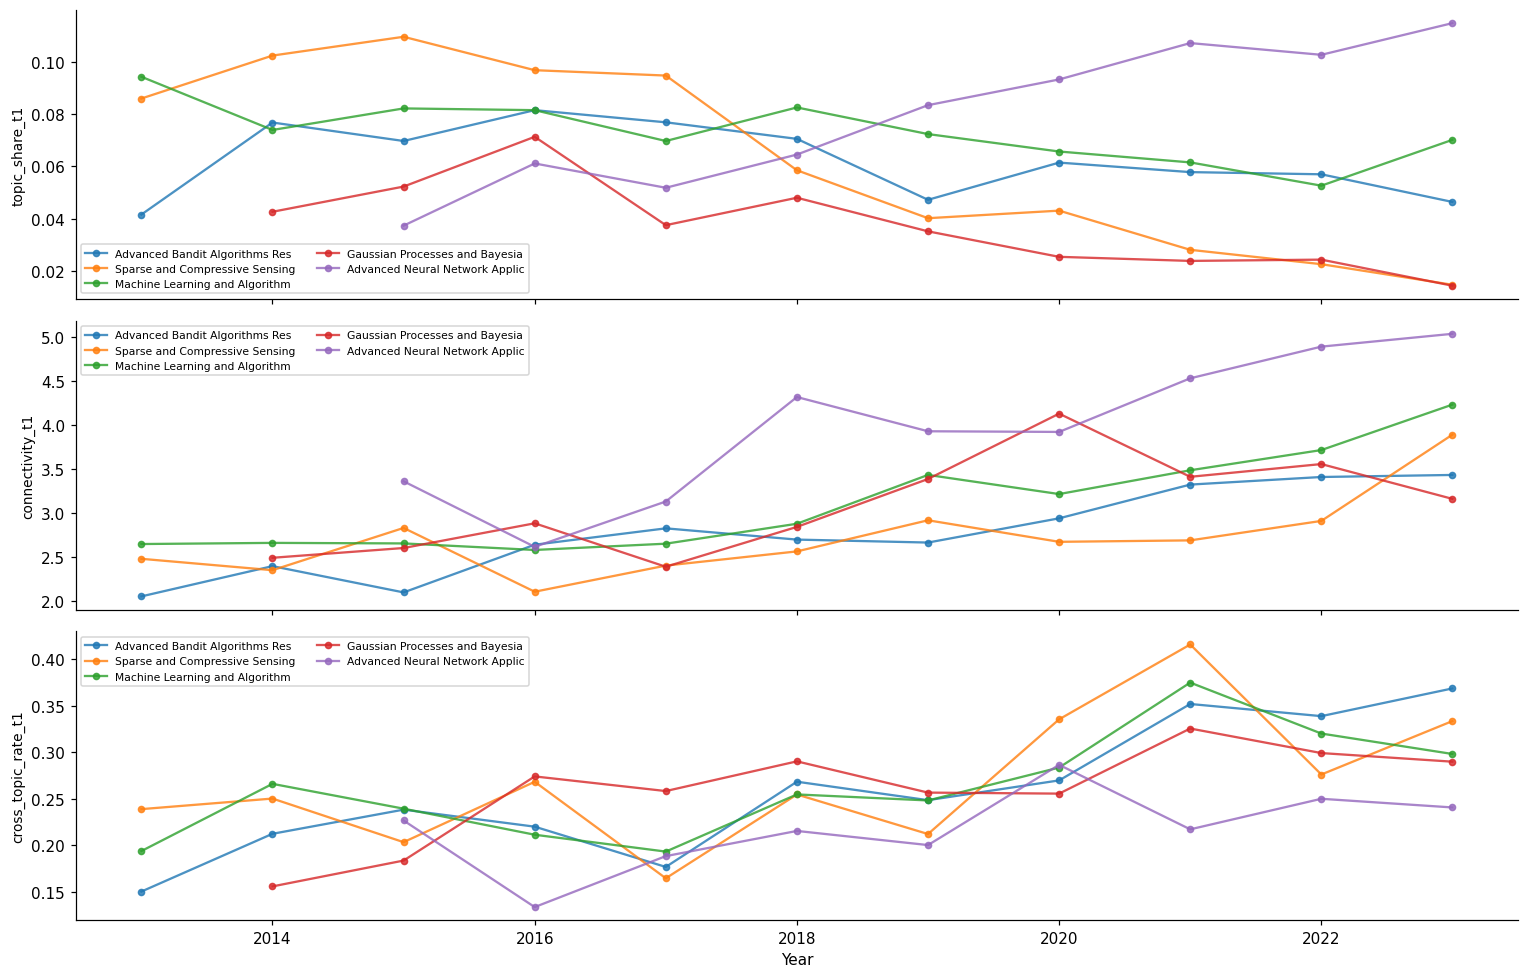

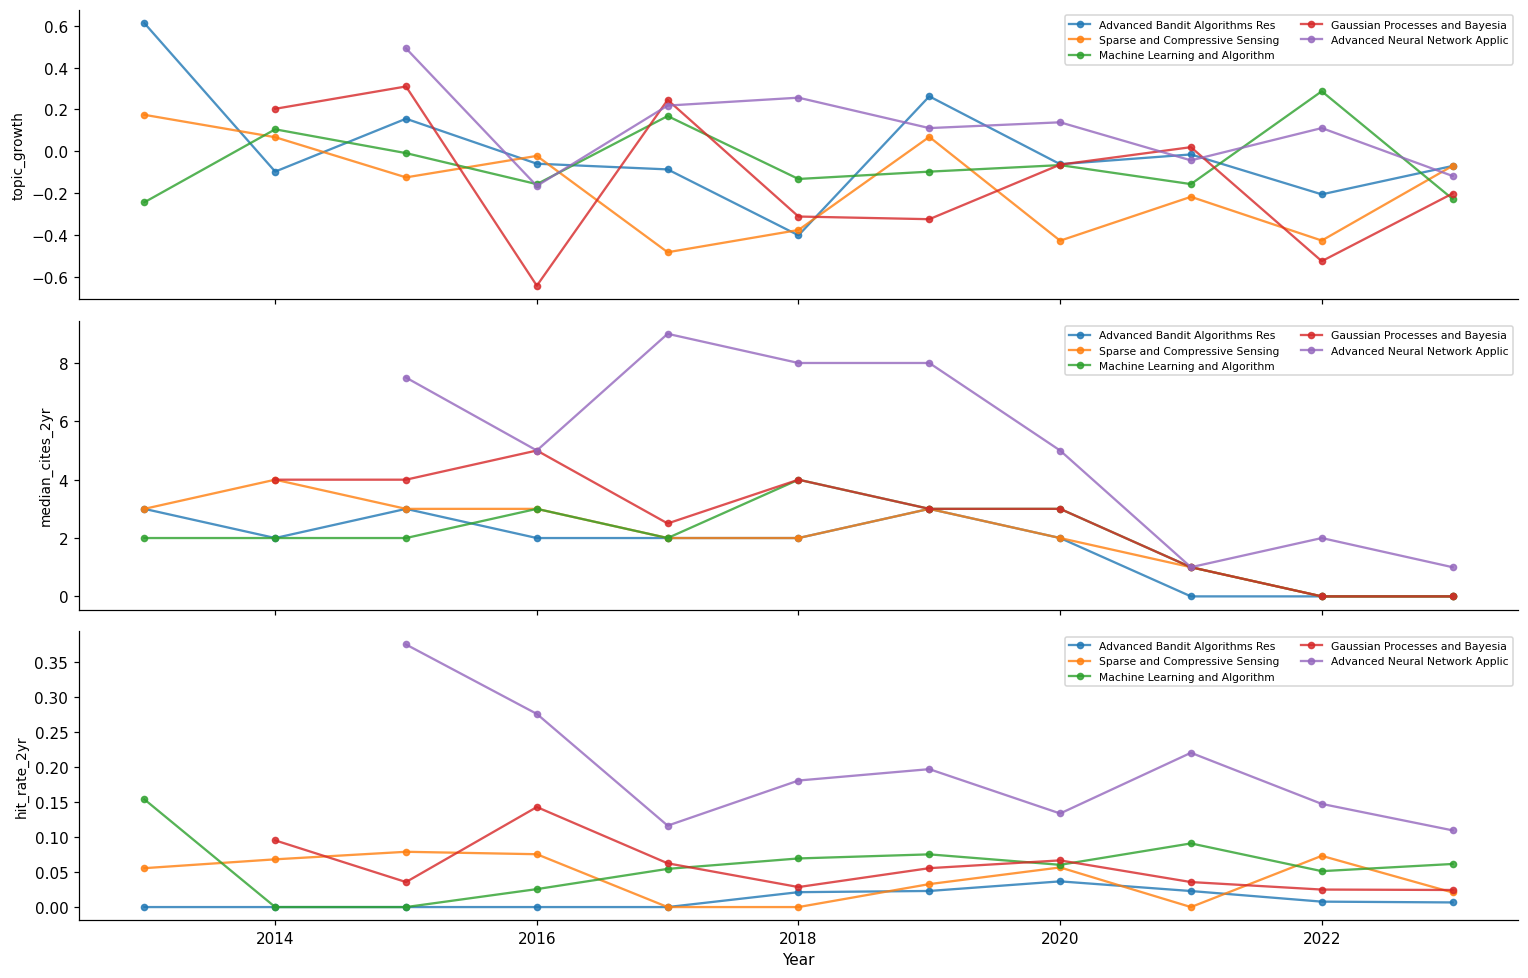

topic_share_t1             0.270
cross_topic_rate_t1        0.987
connectivity_t1            1.448
modularity_t1              2.259
bridge_concentration_t1    2.158
topic_growth               6.292
median_cites_2yr           1.660
hit_rate_2yr               0.659
{'topic_share': (0.5386450290648451, 14), 'connectivity': (0.46479751265167224, 14), 'cross_topic_rate': (0.1515694249264047, 14), 'median_cites_2yr': (0.5766148507954553, 14), 'hit_rate_2yr': (0.3750099566367405, 14)}


In [ ]:
if panel is not None:
    core = [c for c in ['topic_share_t1', 'cross_topic_rate_t1', 'connectivity_t1', 'modularity_t1', 'bridge_concentration_t1', 'topic_growth', 'median_cites_2yr', 'hit_rate_2yr'] if c in panel.columns]
    top_topics = panel.groupby('topic').size().sort_values(ascending=False).head(5).index.tolist()

    for vars_ in [[c for c in ['topic_share_t1', 'connectivity_t1', 'cross_topic_rate_t1'] if c in panel.columns], [c for c in ['topic_growth', 'median_cites_2yr', 'hit_rate_2yr'] if c in panel.columns]]:
        fig, axes = plt.subplots(len(vars_), 1, figsize=(14, 3 * len(vars_)), sharex=True)
        axes = np.atleast_1d(axes)
        for ax, var in zip(axes, vars_):
            for topic in top_topics:
                ts = panel[panel['topic'] == topic].sort_values('year')
                ax.plot(ts['year'], ts[var], 'o-', ms=4, label=topic[:30], alpha=0.8)
            ax.set_ylabel(var, fontsize=9)
            ax.legend(fontsize=7, ncol=2)
        axes[-1].set_xlabel('Year')
        plt.tight_layout()
        plt.show()

    ratios = {}
    for var in core:
        groups = [g[var].dropna().to_numpy() for _, g in panel.groupby('topic') if g[var].dropna().shape[0] >= 3]
        if len(groups) >= 3:
            between = np.var([g.mean() for g in groups])
            within = np.mean([np.var(g) for g in groups])
            ratios[var] = within / between if between > 0 else np.nan
    print(pd.Series(ratios).round(3).to_string())

    ac = {}
    for var in [c for c in ['topic_share', 'connectivity', 'cross_topic_rate', 'median_cites_2yr', 'hit_rate_2yr'] if c in panel.columns]:
        vals = []
        for _, g in panel.groupby('topic'):
            s = g.sort_values('year')[var].dropna()
            if len(s) >= 5:
                r = s.autocorr(lag=1)
                if pd.notna(r):
                    vals.append(r)
        if vals:
            ac[var] = (float(np.mean(vals)), len(vals))
    print(ac)


## 6. Predictor → outcome scatter plots

These are the relationships the DAG should discover (or not).

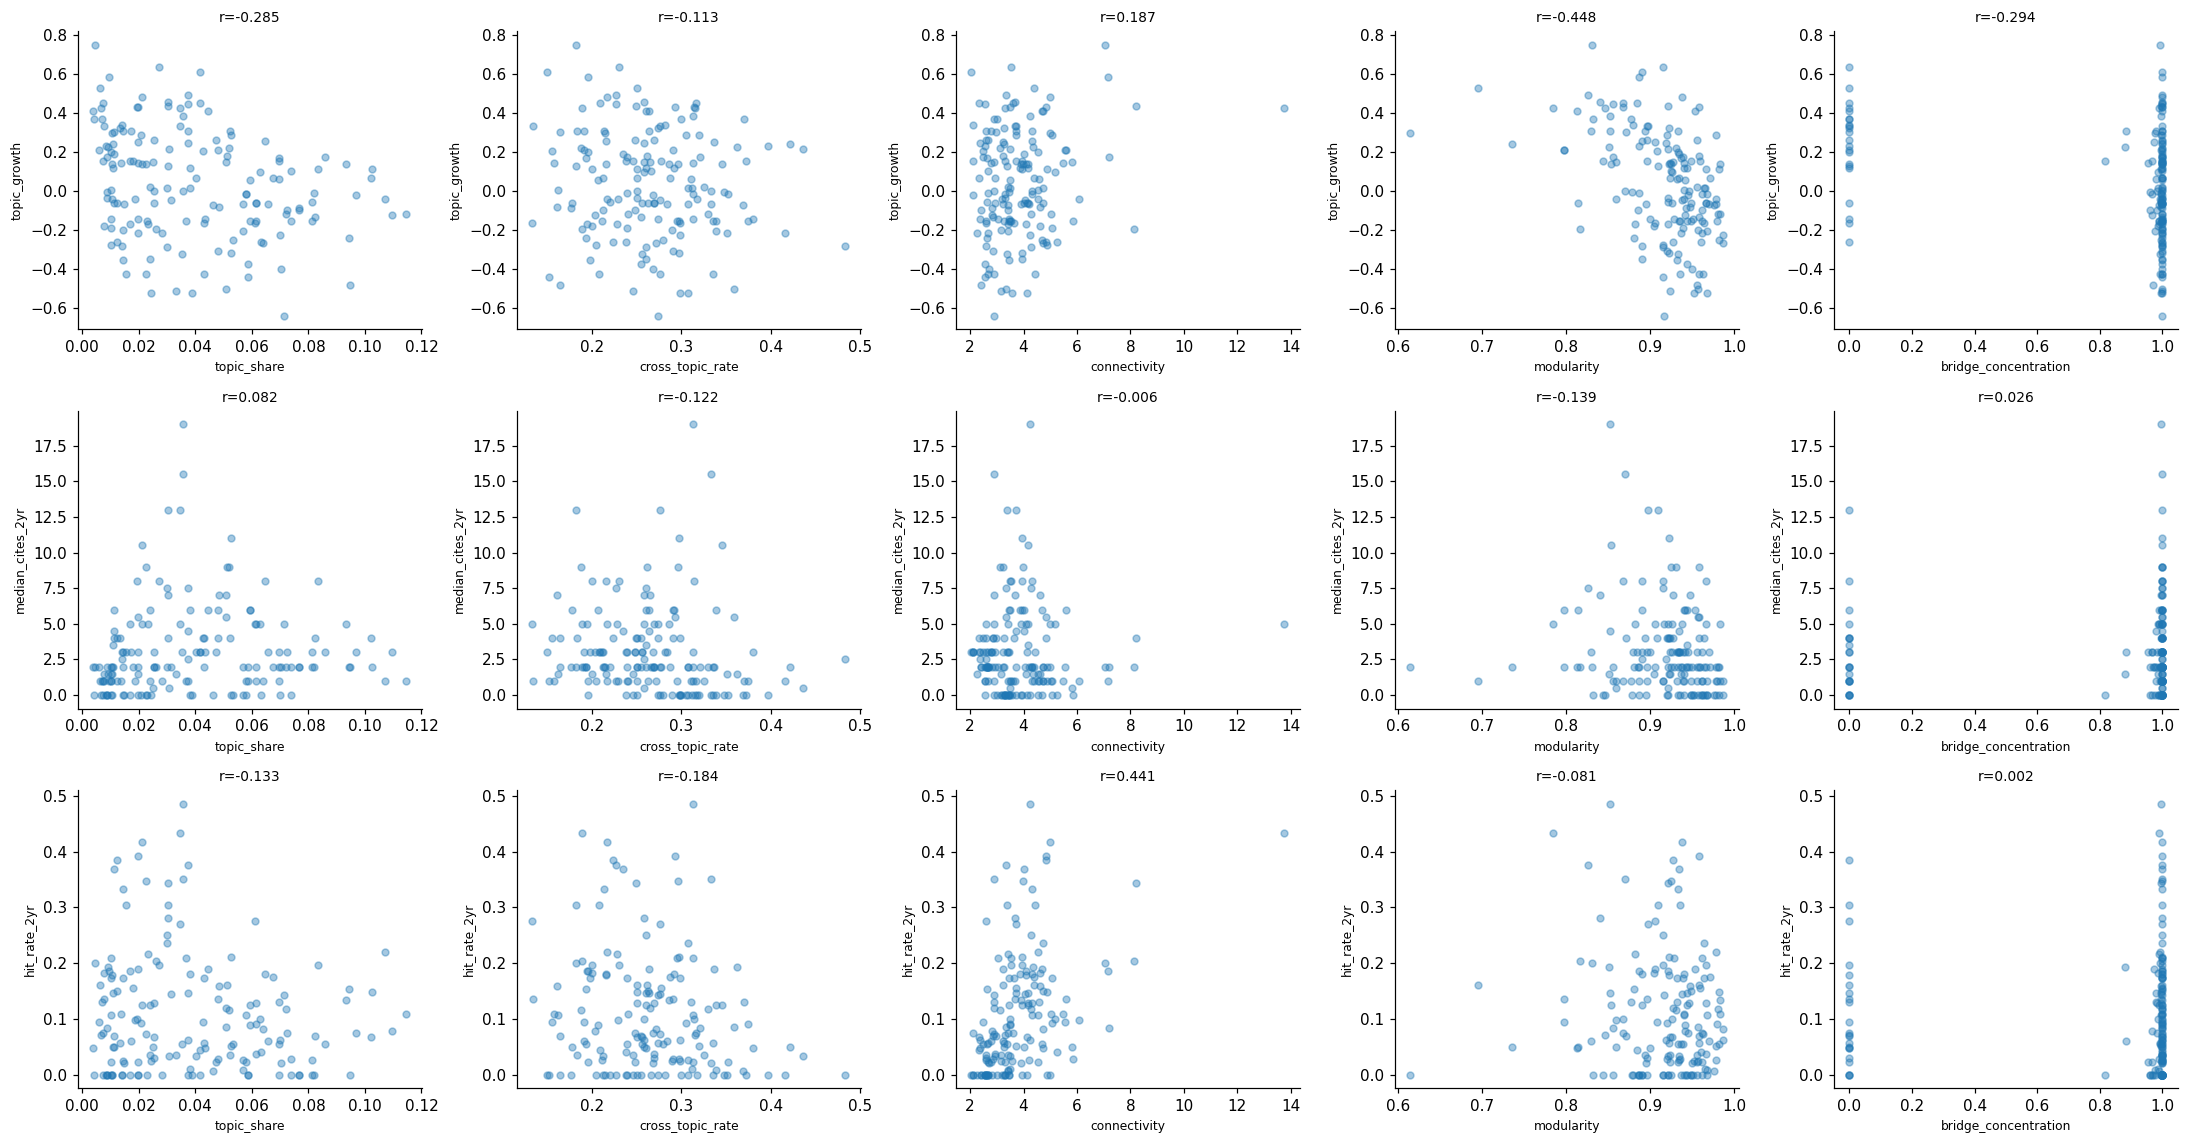

                         topic_share_t1  cross_topic_rate_t1  connectivity_t1  modularity_t1  bridge_concentration_t1  topic_growth  median_cites_2yr  hit_rate_2yr
topic_share_t1                    1.000               -0.131           -0.206          0.426                    0.361        -0.285             0.082        -0.133
cross_topic_rate_t1              -0.131                1.000           -0.153          0.091                    0.080        -0.113            -0.122        -0.184
connectivity_t1                  -0.206               -0.153            1.000         -0.215                    0.081         0.187            -0.006         0.441
modularity_t1                     0.426                0.091           -0.215          1.000                    0.304        -0.448            -0.139        -0.081
bridge_concentration_t1           0.361                0.080            0.081          0.304                    1.000        -0.294             0.026         0.002
topic_growth    

In [ ]:
if panel is not None:
    pred = [c for c in ['topic_share_t1', 'cross_topic_rate_t1', 'connectivity_t1', 'modularity_t1', 'bridge_concentration_t1'] if c in panel.columns]
    outc = [c for c in ['topic_growth', 'median_cites_2yr', 'hit_rate_2yr'] if c in panel.columns]

    fig, axes = plt.subplots(len(outc), len(pred), figsize=(4 * len(pred), 3.5 * len(outc)))
    axes = np.atleast_2d(axes)
    for i, y in enumerate(outc):
        for j, x in enumerate(pred):
            sub = panel[[x, y]].dropna()
            ax = axes[i, j]
            ax.scatter(sub[x], sub[y], alpha=0.4, s=20)
            ax.set_title(f"r={sub[x].corr(sub[y]):.3f}" if len(sub) > 5 else x, fontsize=9)
            ax.set_xlabel(x.replace('_t1', ''), fontsize=8)
            ax.set_ylabel(y, fontsize=8)
    plt.tight_layout()
    plt.show()

    core = [c for c in ['topic_share_t1', 'cross_topic_rate_t1', 'connectivity_t1', 'modularity_t1', 'bridge_concentration_t1', 'topic_growth', 'median_cites_2yr', 'hit_rate_2yr'] if c in panel.columns]
    print(panel[core].corr().round(3).to_string())


## 7. Modularity & bridge concentration quality check

Prof warns: "Modularity may be unstable when graph is too small."

{'valid': 156, 'total': 156, 'mean': 0.9151152748787945, 'min': 0.6149590060862129, 'max': 0.987091316118284}


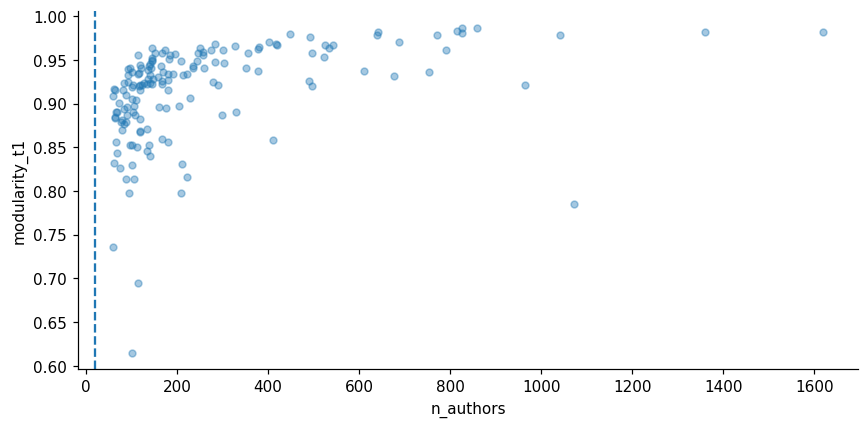

{'bc_valid': 156, 'bc_mean': 0.8525154569217548, 'bc_min': 0.0, 'bc_max': 1.0, 'bc_at_1': 88}


In [ ]:
if panel is not None:
    mod_col = 'modularity_t1' if 'modularity_t1' in panel.columns else 'modularity'
    if mod_col in panel.columns:
        mod = panel[['topic', 'year', 'n_authors', mod_col]].copy()
        valid = mod[mod_col].notna()
        vals = mod.loc[valid, mod_col]
        print({'valid': int(valid.sum()), 'total': int(len(mod)), 'mean': float(vals.mean()) if len(vals) else np.nan, 'min': float(vals.min()) if len(vals) else np.nan, 'max': float(vals.max()) if len(vals) else np.nan})
        sub = mod[['n_authors', mod_col]].dropna()
        if len(sub):
            plt.figure(figsize=(8, 4))
            plt.scatter(sub['n_authors'], sub[mod_col], alpha=0.4, s=20)
            plt.axvline(20, ls='--')
            plt.xlabel('n_authors')
            plt.ylabel(mod_col)
            plt.tight_layout()
            plt.show()

    if 'bridge_concentration_t1' in panel.columns:
        bc = panel['bridge_concentration_t1'].dropna()
        print({'bc_valid': int(panel['bridge_concentration_t1'].notna().sum()), 'bc_mean': float(bc.mean()) if len(bc) else np.nan, 'bc_min': float(bc.min()) if len(bc) else np.nan, 'bc_max': float(bc.max()) if len(bc) else np.nan, 'bc_at_1': int((panel['bridge_concentration_t1'] == 1.0).sum())})


## 8. DAG readiness scorecard

In [ ]:
checks = []

def add(name, ok, detail):
    checks.append((name, bool(ok), detail))
    print(('PASS' if ok else 'FAIL'), name, detail)

if panel is not None:
    core = [c for c in ['topic_share_t1', 'cross_topic_rate_t1', 'connectivity_t1', 'modularity_t1', 'bridge_concentration_t1', 'topic_growth', 'median_cites_2yr', 'hit_rate_2yr'] if c in panel.columns]
    complete = panel[core].notna().all(axis=1).mean()
    skew_bad = [c for c in core if panel[c].notna().sum() > 5 and abs(panel[c].skew()) > 5]

    add('core_vars', len(core) == 8, len(core))
    add('N>=100', len(panel) >= 100, len(panel))
    add('topics>=20', panel['topic'].nunique() >= 20, panel['topic'].nunique())
    add('span>=8', panel['year'].max() - panel['year'].min() + 1 >= 8, f"{panel['year'].min()}-{panel['year'].max()}")
    add('complete>=85%', complete >= 0.85, f'{complete:.1%}')
    add('|skew|<5', len(skew_bad) == 0, skew_bad)
    add('lag_cols', any(c.endswith('_t1') for c in panel.columns), sum(c.endswith('_t1') for c in panel.columns))

if vardesc is not None:
    add('vardesc>=8', len(vardesc.get('variables', [])) >= 8, len(vardesc.get('variables', [])))

dag_json = f'{EXPORT_DIR}/dag_constraints.json'
if os.path.exists(dag_json):
    constraints = json.load(open(dag_json))
    add('constraints', len(constraints.get('forbidden_edges', [])) > 0, len(constraints.get('forbidden_edges', [])))

passed = sum(x[1] for x in checks)
print(passed, len(checks))


PASS core_vars 8
PASS N>=100 156
PASS topics>=20 29
PASS span>=8 2013-2023
PASS complete>=85% 100.0%
PASS |skew|<5 []
PASS lag_cols 5
PASS vardesc>=8 8
PASS constraints 15
9 9
